# Interpolation

## Setup and configuration

In [74]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 6),
    "axes.grid": True,
})

COLUMNS = [
    "Freq_Hz",
    "Time_s",
    "Eps_real",
    "Eps_imag",
    "Temp_K",
    "MTime_s",
    "Phi_deg",
    "Z_real_Ohm",
    "Z_imag_Ohm",
    "TanPhi",
]

TIME_COL = "Time_Relative_s"
INTERPOLATED_VALUE_COLS = ("Eps_real",)

MATERIAL = "PEI5mgmL"
TEMPERATURE = "50°C"
MODE = "Abs"
PLOT_TIME_S = 4000
SELECTED_FILE = f"{MATERIAL}_{TEMPERATURE}_{MODE}.TXT"

# Point number directly before the atmosphere switch for each measurement series.
manual_switch_points = {
    ("PEI2mgmL", "50°C", "Abs"): 132,
    ("PEI2mgmL", "50°C", "Des"): 145,
    ("PEI2mgmL", "90°C", "Abs"): 151,
    ("PEI2mgmL", "90°C", "Des"): 152,
    ("PEI5mgmL", "50°C", "Abs"): 127,
    ("PEI5mgmL", "50°C", "Des"): 145,
    ("PEI5mgmL", "60°C", "Abs"): 127,
    ("PEI5mgmL", "60°C", "Des"): 145,
    ("PEI5mgmL", "70°C", "Abs"): 127,
    ("PEI5mgmL", "70°C", "Des"): 145,
    ("PEI5mgmL", "80°C", "Abs"): 128,
    ("PEI5mgmL", "80°C", "Des"): 128,
    ("PEI5mgmL", "90°C", "Abs"): 128,
    ("PEI5mgmL", "90°C", "Des"): 128,
}


def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "data" / "Daten final").exists():
            return path
    raise FileNotFoundError("Could not find the project root with data/Daten final.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "Daten final"
DATA_DIR / SELECTED_FILE

WindowsPath('c:/Users/Max/Documents/bachelor thesis/data/Daten final/PEI5mgmL_50°C_Abs.TXT')

## Load data and set relative time

In [56]:
def load_measurements(data_dir=DATA_DIR, selected_file=None):
    if selected_file is None:
        file_paths = sorted(data_dir.glob("*.TXT")) + sorted(data_dir.glob("*.txt"))
    else:
        file_path = data_dir / selected_file
        if not file_path.exists():
            raise FileNotFoundError(f"File not found: {file_path}")
        file_paths = [file_path]

    if not file_paths:
        raise FileNotFoundError(f"No .TXT files found in: {data_dir}")

    frames = []
    for path in file_paths:
        df = pd.read_csv(
            path,
            sep=r"\s+",
            skiprows=4,
            names=COLUMNS,
            encoding="latin1",
            engine="python",
        )

        parts = path.stem.split("_")
        if len(parts) >= 3:
            material, temperature, mode = parts[:3]
        else:
            material, temperature, mode = path.stem, None, None

        first_freq = df["Freq_Hz"].iloc[0]
        df["Spectrum_ID"] = (df["Freq_Hz"] == first_freq).cumsum() - 1
        df["Spectrum_Number"] = df["Spectrum_ID"] + 1
        df["Point_Number"] = range(1, len(df) + 1)
        df["Material"] = material
        df["Temperature"] = temperature
        df["Mode"] = mode
        df["Source_File"] = path.name

        frames.append(df)

    return pd.concat(frames, ignore_index=True)


def add_relative_switch_time(df, switch_points):
    df = df.copy()
    switch_time_rows = []

    for dataset_key, dataset in df.groupby(["Material", "Temperature", "Mode"], dropna=False):
        switch_point_number = switch_points.get(dataset_key)
        if switch_point_number is None:
            raise ValueError(
                "Missing Switch_Point_Number for series: "
                f"Material={dataset_key[0]}, Temperature={dataset_key[1]}, Mode={dataset_key[2]}"
            )

        switch_point = dataset[dataset["Point_Number"] == switch_point_number]
        next_point = dataset[dataset["Point_Number"] == switch_point_number + 1]

        if switch_point.empty or next_point.empty:
            raise ValueError(
                "The atmosphere switch must lie between two existing measurement points: "
                f"Material={dataset_key[0]}, Temperature={dataset_key[1]}, Mode={dataset_key[2]}, "
                f"Switch_Point_Number={switch_point_number}"
            )

        switch_time = float((switch_point["MTime_s"].iloc[0] + next_point["MTime_s"].iloc[0]) / 2)
        switch_spectrum_id = int(switch_point["Spectrum_ID"].iloc[0])

        switch_time_rows.append({
            "Material": dataset_key[0],
            "Temperature": dataset_key[1],
            "Mode": dataset_key[2],
            "Switch_Point_Number": int(switch_point_number),
            "Switch_Spectrum_ID": switch_spectrum_id,
            "Switch_Time_s": switch_time,
        })

    switch_times = pd.DataFrame(switch_time_rows)
    df = df.merge(switch_times, on=["Material", "Temperature", "Mode"], how="left")
    df["Time_Relative_s"] = df["MTime_s"] - df["Switch_Time_s"]
    return df, switch_times

In [57]:
df_all = load_measurements(selected_file=SELECTED_FILE)
df_all, switch_times = add_relative_switch_time(df_all, manual_switch_points)

print(f"Loaded rows: {len(df_all):,}")
print(switch_times.to_string(index=False))

Loaded rows: 2,904
Material Temperature Mode  Switch_Point_Number  Switch_Spectrum_ID  Switch_Time_s
PEI5mgmL        50°C  Abs                  127                   5         420.43


## Interpolate complete spectra

In [58]:
def _linear_at(target_time, times, values):
    if len(times) < 2:
        return np.nan

    x0, x1 = float(times[0]), float(times[1])
    y0, y1 = float(values[0]), float(values[1])

    if x0 == x1:
        return np.nan

    return y0 + (target_time - x0) * (y1 - y0) / (x1 - x0)


def _insert_switch_support_point(freq_data, value_col, time_col=TIME_COL, target_time=0):
    before = freq_data[freq_data[time_col] < target_time].tail(2)
    if len(before) < 2:
        return freq_data[[time_col, value_col]].dropna().sort_values(time_col)

    switch_value = _linear_at(
        target_time,
        before[time_col].to_numpy(),
        before[value_col].to_numpy(),
    )

    support_points = freq_data[[time_col, value_col]].dropna().copy()
    support_points = support_points[~np.isclose(support_points[time_col], target_time)]
    support_points = pd.concat(
        [
            support_points,
            pd.DataFrame({time_col: [float(target_time)], value_col: [switch_value]}),
        ],
        ignore_index=True,
    )
    support_points = support_points.sort_values(time_col)
    return support_points.groupby(time_col, as_index=False)[value_col].mean()


def interpolate_complete_spectra(
    df,
    time_col=TIME_COL,
    freq_col="Freq_Hz",
    value_cols=INTERPOLATED_VALUE_COLS,
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
    drop_incomplete=True,
    include_switch_time=True,
):
    rows = []
    metadata_cols = ["Switch_Point_Number", "Switch_Spectrum_ID", "Switch_Time_s"]

    for dataset_key, dataset in df.groupby(list(dataset_cols), dropna=False):
        dataset_key = dataset_key if isinstance(dataset_key, tuple) else (dataset_key,)
        dataset_meta = dict(zip(dataset_cols, dataset_key))

        target_times = np.sort(dataset[time_col].dropna().unique())
        if include_switch_time and not np.isclose(target_times, 0).any():
            target_times = np.sort(np.append(target_times, 0.0))

        frequencies = np.sort(dataset[freq_col].dropna().unique())
        dataset_metadata = {
            col: dataset[col].dropna().iloc[0]
            for col in metadata_cols
            if col in dataset.columns and not dataset[col].dropna().empty
        }

        interpolated_by_freq = {}
        for freq in frequencies:
            needed_cols = [time_col, freq_col, "Spectrum_ID", *metadata_cols, *value_cols]
            freq_data = (
                dataset.loc[dataset[freq_col] == freq, [col for col in needed_cols if col in dataset.columns]]
                .dropna(subset=[time_col])
                .sort_values(time_col)
            )

            grouped_values = {value_col: "mean" for value_col in value_cols}
            grouped_values.update({"Spectrum_ID": "first"})
            for col in metadata_cols:
                if col in freq_data.columns:
                    grouped_values[col] = "first"
            freq_data = freq_data.groupby(time_col, as_index=False).agg(grouped_values)

            interpolated_values = {}
            for value_col in value_cols:
                support_points = _insert_switch_support_point(
                    freq_data,
                    value_col,
                    time_col=time_col,
                    target_time=0,
                )
                support_times = support_points[time_col].to_numpy()
                support_values = support_points[value_col].to_numpy()

                interpolated_values[value_col] = np.interp(
                    target_times,
                    support_times,
                    support_values,
                    left=np.nan,
                    right=np.nan,
                )

            interpolated_by_freq[freq] = interpolated_values

        for spectrum_id, target_time in enumerate(target_times):
            for freq in frequencies:
                row = {
                    **dataset_meta,
                    **dataset_metadata,
                    "Interpolated_Spectrum_ID": spectrum_id,
                    time_col: target_time,
                    freq_col: freq,
                    "Is_Switch_Spectrum": bool(np.isclose(target_time, 0)),
                }
                for value_col in value_cols:
                    row[value_col] = interpolated_by_freq[freq][value_col][spectrum_id]
                rows.append(row)

    interpolated = pd.DataFrame(rows)

    if drop_incomplete:
        complete_ids = [*dataset_cols, "Interpolated_Spectrum_ID"]
        complete_mask = interpolated.groupby(complete_ids, dropna=False)[list(value_cols)].transform(
            lambda values: values.notna().all()
        )
        interpolated = interpolated[complete_mask.all(axis=1)].reset_index(drop=True)

    return interpolated

In [59]:
df_interpolated_complete = interpolate_complete_spectra(df_all)

interpolation_summary = (
    df_interpolated_complete.groupby(["Source_File", "Material", "Temperature", "Mode"], dropna=False)
    .agg(
        spectra=("Interpolated_Spectrum_ID", "nunique"),
        frequencies=("Freq_Hz", "nunique"),
        first_time_relative_s=("Time_Relative_s", "min"),
        last_time_relative_s=("Time_Relative_s", "max"),
        switch_spectra=("Is_Switch_Spectrum", "sum"),
    )
    .reset_index()
)

print(interpolation_summary.to_string(index=False))
df_interpolated_complete[df_interpolated_complete["Is_Switch_Spectrum"]].head()

          Source_File Material Temperature Mode  spectra  frequencies  first_time_relative_s  last_time_relative_s  switch_spectra
PEI5mgmL_50°C_Abs.TXT PEI5mgmL        50°C  Abs     2859           24                 -340.5               8954.47              24


,Source_File,Material,Temperature,Mode,Switch_Point_Number,Switch_Spectrum_ID,Switch_Time_s,Interpolated_Spectrum_ID,Time_Relative_s,Freq_Hz,Is_Switch_Spectrum,Eps_real
2496,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,100.00,True,6.215676
2497,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,150.00,True,6.175619
2498,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,225.00,True,6.150318
2499,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,337.50,True,6.119042
2500,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,127,5,420.43,127,0.0,506.25,True,6.087711


## Derivatives

In [60]:
def derive_eps_real_by_frequency(
    df,
    value_col="Eps_real",
    freq_col="Freq_Hz",
    time_col=TIME_COL,
    spectrum_col="Interpolated_Spectrum_ID",
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
):
    rows = []
    group_cols = [*dataset_cols, spectrum_col, time_col]

    for group_key, spectrum in df.groupby(group_cols, dropna=False):
        spectrum = spectrum.sort_values(freq_col)
        frequencies = spectrum[freq_col].to_numpy()
        eps_real = spectrum[value_col].to_numpy()

        omega = 2 * np.pi * frequencies
        ln_omega = np.log(omega)
        derivative = -np.pi / 2 * np.diff(eps_real) / np.diff(ln_omega)
        omega_mid = np.exp((ln_omega[:-1] + ln_omega[1:]) / 2)
        freq_mid = omega_mid / (2 * np.pi)

        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        meta = dict(zip(group_cols, group_key))
        for freq, omega_value, derivative_value in zip(freq_mid, omega_mid, derivative):
            rows.append({
                **meta,
                "Freq_Hz_mid": freq,
                "Omega_rad_s": omega_value,
                "Eps_real_derivative": derivative_value,
            })

    return pd.DataFrame(rows)


def derive_raw_eps_real_by_frequency(
    df,
    value_col="Eps_real",
    freq_col="Freq_Hz",
    time_col=TIME_COL,
    spectrum_col="Spectrum_ID",
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
):
    rows = []
    group_cols = [*dataset_cols, spectrum_col]

    for group_key, spectrum in df.groupby(group_cols, dropna=False):
        spectrum = spectrum.sort_values(freq_col)
        frequencies = spectrum[freq_col].to_numpy()
        eps_real = spectrum[value_col].to_numpy()
        times = spectrum[time_col].to_numpy()

        if len(frequencies) < 2:
            continue

        omega = 2 * np.pi * frequencies
        ln_omega = np.log(omega)
        derivative = -np.pi / 2 * np.diff(eps_real) / np.diff(ln_omega)
        omega_mid = np.exp((ln_omega[:-1] + ln_omega[1:]) / 2)
        freq_mid = omega_mid / (2 * np.pi)
        time_mid = (times[:-1] + times[1:]) / 2
        spectrum_time = np.nanmedian(times)

        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        meta = dict(zip(group_cols, group_key))
        for freq, omega_value, time_value, derivative_value in zip(freq_mid, omega_mid, time_mid, derivative):
            rows.append({
                **meta,
                "Freq_Hz_mid": freq,
                "Omega_rad_s": omega_value,
                "Raw_Time_Relative_s": time_value,
                "Spectrum_Time_Relative_s": spectrum_time,
                "Eps_real_derivative_raw": derivative_value,
            })

    return pd.DataFrame(rows)

In [61]:
df_derivative = derive_eps_real_by_frequency(df_interpolated_complete)
df_raw_derivative = derive_raw_eps_real_by_frequency(df_all)

print(f"Interpolated derivative rows: {len(df_derivative):,}")
print(f"Raw derivative rows: {len(df_raw_derivative):,}")
df_derivative.head()

Interpolated derivative rows: 65,757
Raw derivative rows: 2,783


,Source_File,Material,Temperature,Mode,Interpolated_Spectrum_ID,Time_Relative_s,Freq_Hz_mid,Omega_rad_s,Eps_real_derivative
0,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,122.474487,769.529898,0.132381
1,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,183.711731,1154.294847,0.119029
2,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,275.567596,1731.442271,0.118800
3,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,413.351394,2597.163406,0.123492
4,PEI5mgmL_50°C_Abs.TXT,PEI5mgmL,50°C,Abs,23,-340.5,620.029132,3895.757935,0.132204


## Step height over time

In [62]:
def calculate_eps_real_step_height(
    df,
    value_col="Eps_real",
    freq_col="Freq_Hz",
    time_col=TIME_COL,
    spectrum_col="Interpolated_Spectrum_ID",
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
    ignored_last_points=3,
):
    rows = []
    group_cols = [*dataset_cols, spectrum_col, time_col]

    for group_key, spectrum in df.groupby(group_cols, dropna=False):
        spectrum = spectrum.sort_values(freq_col).reset_index(drop=True)
        if len(spectrum) <= ignored_last_points:
            continue

        first = spectrum.iloc[0]
        comparison = spectrum.iloc[-(ignored_last_points + 1)]
        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        meta = dict(zip(group_cols, group_key))

        rows.append({
            **meta,
            "First_Freq_Hz": first[freq_col],
            "Comparison_Freq_Hz": comparison[freq_col],
            "First_Eps_real": first[value_col],
            "Comparison_Eps_real": comparison[value_col],
            "Eps_real_Step_Height": first[value_col] - comparison[value_col],
        })

    return pd.DataFrame(rows).sort_values([*dataset_cols, time_col]).reset_index(drop=True)


def as_selection_list(selection):
    if selection is None:
        return None
    if isinstance(selection, str):
        return [selection]
    return list(selection)

In [63]:
df_all_series = load_measurements(selected_file=None)
df_all_series, switch_times_all_series = add_relative_switch_time(df_all_series, manual_switch_points)
df_interpolated_all_series = interpolate_complete_spectra(df_all_series)
df_eps_real_step_height = calculate_eps_real_step_height(df_interpolated_all_series)

print(f"Step-height rows: {len(df_eps_real_step_height):,}")
df_eps_real_step_height.head()

Step-height rows: 57,278


,Source_File,Material,Temperature,Mode,Interpolated_Spectrum_ID,Time_Relative_s,First_Freq_Hz,Comparison_Freq_Hz,First_Eps_real,Comparison_Eps_real,Eps_real_Step_Height
0,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,23,-372.255,100.0,332530.0,1.833750,1.542309,0.291440
1,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,24,-362.725,100.0,332530.0,1.833900,1.542321,0.291579
2,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,25,-360.285,100.0,332530.0,1.833888,1.542324,0.291564
3,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,26,-355.305,100.0,332530.0,1.833863,1.542330,0.291533
4,PEI2mgmL_50°C_Abs.TXT,PEI2mgmL,50°C,Abs,27,-352.625,100.0,332530.0,1.833850,1.542334,0.291517


## Plot helpers

In [64]:
def nearest_available_time(df, target_time, time_col=TIME_COL):
    available_times = np.sort(df[time_col].dropna().unique())
    if len(available_times) == 0:
        raise ValueError("No available times found.")
    return available_times[np.abs(available_times - target_time).argmin()]


def filter_series(df, material=MATERIAL, temperature=TEMPERATURE, mode=MODE):
    return df[
        (df["Temperature"] == temperature)
        & (df["Material"] == material)
        & (df["Mode"] == mode)
    ].copy()


def choose_log_spaced_frequencies(df, count=14, freq_col="Freq_Hz"):
    frequencies = np.sort(df[freq_col].dropna().unique())
    target_freqs = np.geomspace(frequencies.min(), frequencies.max(), count)
    chosen = np.array([
        frequencies[np.abs(frequencies - freq).argmin()]
        for freq in target_freqs
    ])
    return np.unique(chosen)


def plot_step_height(
    df,
    materials=("PEI5mgmL",),
    temperatures=None,
    modes=("Abs", "Des"),
):
    plot_df = df.copy()
    selection_filters = {
        "Material": as_selection_list(materials),
        "Temperature": as_selection_list(temperatures),
        "Mode": as_selection_list(modes),
    }

    for column, allowed_values in selection_filters.items():
        if allowed_values is not None:
            plot_df = plot_df[plot_df[column].isin(allowed_values)]

    if plot_df.empty:
        available = df[["Material", "Temperature", "Mode"]].drop_duplicates()
        raise ValueError(
            "No step-height data found for this selection. Available series:\n"
            + available.to_string(index=False)
        )

    fig, ax = plt.subplots(figsize=(11, 7))
    for keys, series in plot_df.groupby(["Material", "Temperature", "Mode"], dropna=False):
        material, temperature, mode = keys
        series = series.sort_values(TIME_COL)
        ax.plot(
            series[TIME_COL],
            series["Eps_real_Step_Height"],
            marker="o",
            markersize=2.5,
            linewidth=1,
            label=f"{material} {temperature} {mode}",
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlabel("Time relative to atmosphere switch (s, symlog scale)")
    ax.set_ylabel("Eps real step height")
    ax.set_title("Step height over time from interpolated spectra")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_interpolated_spectrum(df, material=MATERIAL, temperature=TEMPERATURE, mode=MODE, target_time=PLOT_TIME_S, y_col="Eps_real"):
    plot_base = filter_series(df, material, temperature, mode)
    if plot_base.empty:
        raise ValueError("No interpolated data found for this selection.")

    plot_time = nearest_available_time(plot_base, target_time)
    plot_df = plot_base[plot_base[TIME_COL] == plot_time].sort_values("Freq_Hz")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(plot_df["Freq_Hz"], plot_df[y_col], marker="o", markersize=3)
    ax.set_xscale("log")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel(y_col)
    ax.set_title(f"Interpolated spectrum at t_rel = {plot_time:.2f} s")
    ax.grid(True, which="both")
    plt.tight_layout()
    plt.show()


def plot_interpolation_near_switch(
    raw_df,
    interpolated_df,
    material=MATERIAL,
    temperature=TEMPERATURE,
    mode=MODE,
    y_col="Eps_real",
    plot_window_s=90,
    frequency_count=14,
):
    raw_base = filter_series(raw_df, material, temperature, mode)
    interpolated_base = filter_series(interpolated_df, material, temperature, mode)

    if raw_base.empty or interpolated_base.empty:
        raise ValueError("No data found for this selection.")

    raw_window = raw_base[raw_base[TIME_COL].between(-plot_window_s, plot_window_s)]
    interpolated_window = interpolated_base[interpolated_base[TIME_COL].between(-plot_window_s, plot_window_s)]
    switch_spectrum = interpolated_base[interpolated_base["Is_Switch_Spectrum"]]

    freqs_for_plot = choose_log_spaced_frequencies(raw_base, count=frequency_count)
    colors = plt.cm.viridis(np.linspace(0, 1, len(freqs_for_plot)))

    fig, ax = plt.subplots(figsize=(11, 7))
    for freq, color in zip(freqs_for_plot, colors):
        raw_freq = raw_window[raw_window["Freq_Hz"] == freq].sort_values(TIME_COL)
        int_freq = interpolated_window[interpolated_window["Freq_Hz"] == freq].sort_values(TIME_COL)
        switch_freq = switch_spectrum[switch_spectrum["Freq_Hz"] == freq]
        label = f"log(f)={np.log10(freq):.2f}"

        ax.plot(int_freq[TIME_COL], int_freq[y_col], color=color, linewidth=1, alpha=0.65)
        ax.scatter(int_freq[TIME_COL], int_freq[y_col], facecolors="none", edgecolors=[color], s=28, linewidths=1)
        ax.scatter(raw_freq[TIME_COL], raw_freq[y_col], color=color, s=28, label=label, zorder=3)

        if not switch_freq.empty:
            ax.scatter(
                switch_freq[TIME_COL],
                switch_freq[y_col],
                color=color,
                marker="D",
                s=44,
                edgecolors="black",
                linewidths=0.5,
                zorder=4,
            )

    ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Atmosphere switch")
    ax.set_xlabel("Time relative to atmosphere switch (s)")
    ax.set_ylabel(y_col)
    ax.set_title(f"Interpolation near atmosphere switch | {material}-{temperature}-{mode}")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Frequency", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_derivative_spectrum(df, material=MATERIAL, temperature=TEMPERATURE, mode=MODE, target_time=PLOT_TIME_S):
    plot_base = filter_series(df, material, temperature, mode)
    if plot_base.empty:
        raise ValueError("No derivative data found for this selection.")

    plot_time = nearest_available_time(plot_base, target_time)
    plot_df = plot_base[plot_base[TIME_COL] == plot_time].sort_values("Omega_rad_s")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(plot_df["Omega_rad_s"], plot_df["Eps_real_derivative"], marker="o", markersize=3)
    ax.set_xscale("log")
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlabel("Angular frequency omega (rad/s)")
    ax.set_ylabel("Eps real derivative")
    ax.set_title(f"Derivative of eps real at t_rel = {plot_time:.2f} s")
    ax.grid(True, which="both")
    plt.tight_layout()
    plt.show()


def plot_raw_vs_interpolated_derivative(
    interpolated_derivative_df,
    raw_derivative_df,
    material=MATERIAL,
    temperature=TEMPERATURE,
    mode=MODE,
    target_time=PLOT_TIME_S,
):
    interpolated_base = filter_series(interpolated_derivative_df, material, temperature, mode)
    raw_base = filter_series(raw_derivative_df, material, temperature, mode)

    if interpolated_base.empty:
        raise ValueError("No interpolated derivative data found for this selection.")
    if raw_base.empty:
        raise ValueError("No raw derivative data found for this selection.")

    plot_time = nearest_available_time(interpolated_base, target_time)
    interpolated_plot = interpolated_base[interpolated_base[TIME_COL] == plot_time].sort_values("Omega_rad_s")

    raw_spectrum_times = raw_base[["Spectrum_ID", "Spectrum_Time_Relative_s"]].drop_duplicates()
    nearest_raw_index = (raw_spectrum_times["Spectrum_Time_Relative_s"] - plot_time).abs().idxmin()
    raw_spectrum_id = raw_spectrum_times.loc[nearest_raw_index, "Spectrum_ID"]
    raw_plot = raw_base[raw_base["Spectrum_ID"] == raw_spectrum_id].sort_values("Omega_rad_s")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(
        raw_plot["Omega_rad_s"],
        raw_plot["Eps_real_derivative_raw"],
        color="black",
        s=22,
        label="raw data, label: t_rel [min]",
    )
    ax.plot(
        interpolated_plot["Omega_rad_s"],
        interpolated_plot["Eps_real_derivative"],
        color="red",
        label=f"interpolated data at t_rel approx {plot_time / 60:.1f} min",
    )

    for _, row in raw_plot.iterrows():
        raw_time_label = row["Raw_Time_Relative_s"] / 60
        ax.text(
            row["Omega_rad_s"],
            row["Eps_real_derivative_raw"],
            f"{raw_time_label:.1f}",
            fontsize=9,
            ha="left",
            va="bottom",
        )

    if (raw_plot["Eps_real_derivative_raw"] > 0).all() and (interpolated_plot["Eps_real_derivative"] > 0).all():
        ax.set_yscale("log")

    ax.set_xscale("log")
    ax.set_xlabel("Angular frequency omega (rad/s)")
    ax.set_ylabel("Eps real derivative")
    ax.set_title(f"Raw data vs interpolation | {material}-{temperature}-{mode}")
    ax.grid(True, which="both")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Example plots

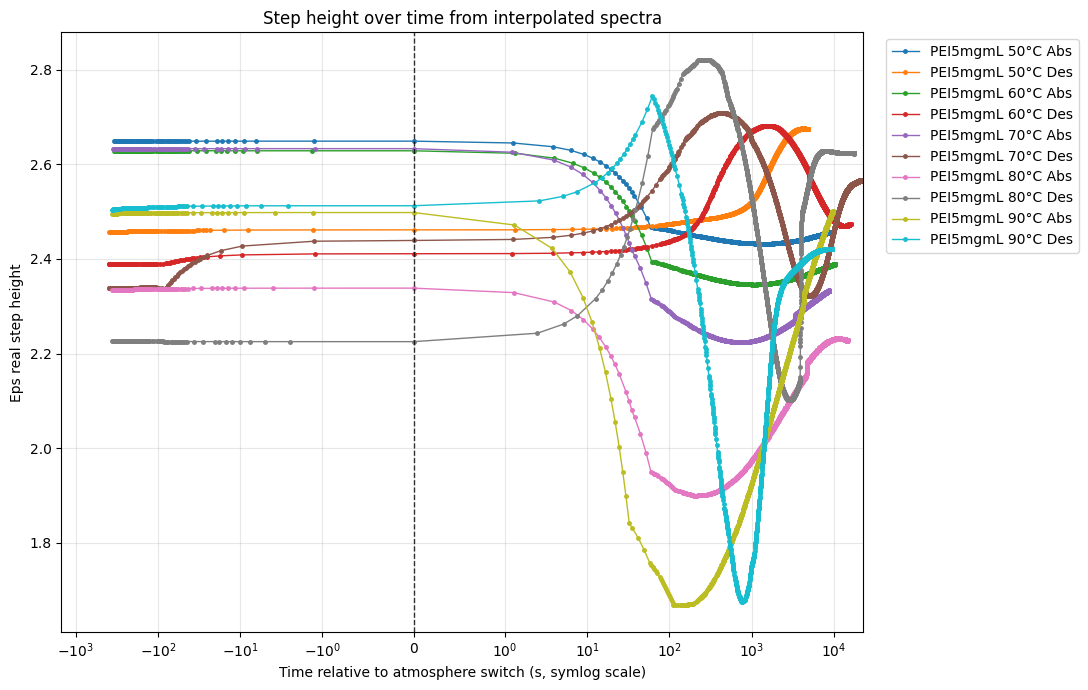

In [65]:
plot_step_height(
    df_eps_real_step_height,
    materials=("PEI5mgmL",),
    temperatures=None,
    modes=("Abs", "Des"),
)

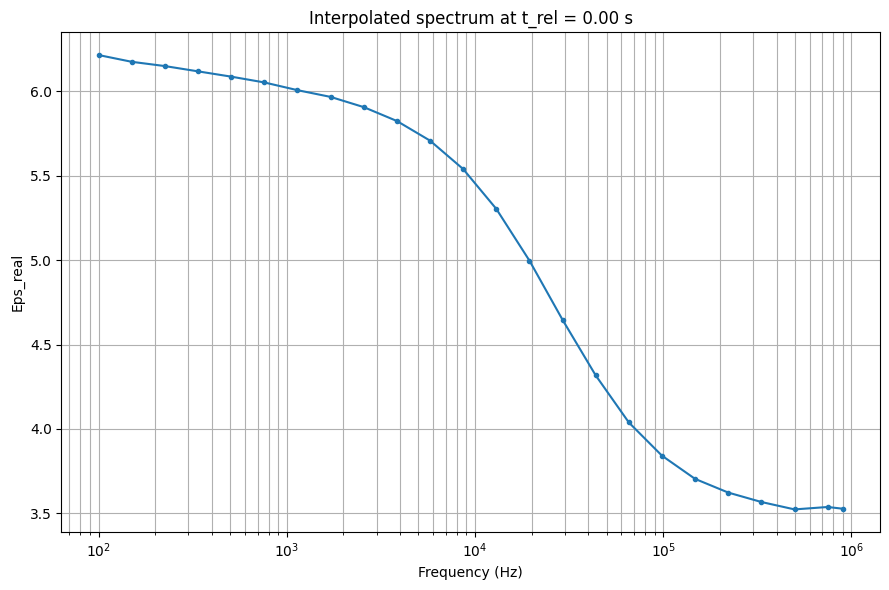

In [66]:
plot_interpolated_spectrum(
    df_interpolated_complete,
    material=MATERIAL,
    temperature=TEMPERATURE,
    mode=MODE,
    target_time=PLOT_TIME_S,
    y_col="Eps_real",
)

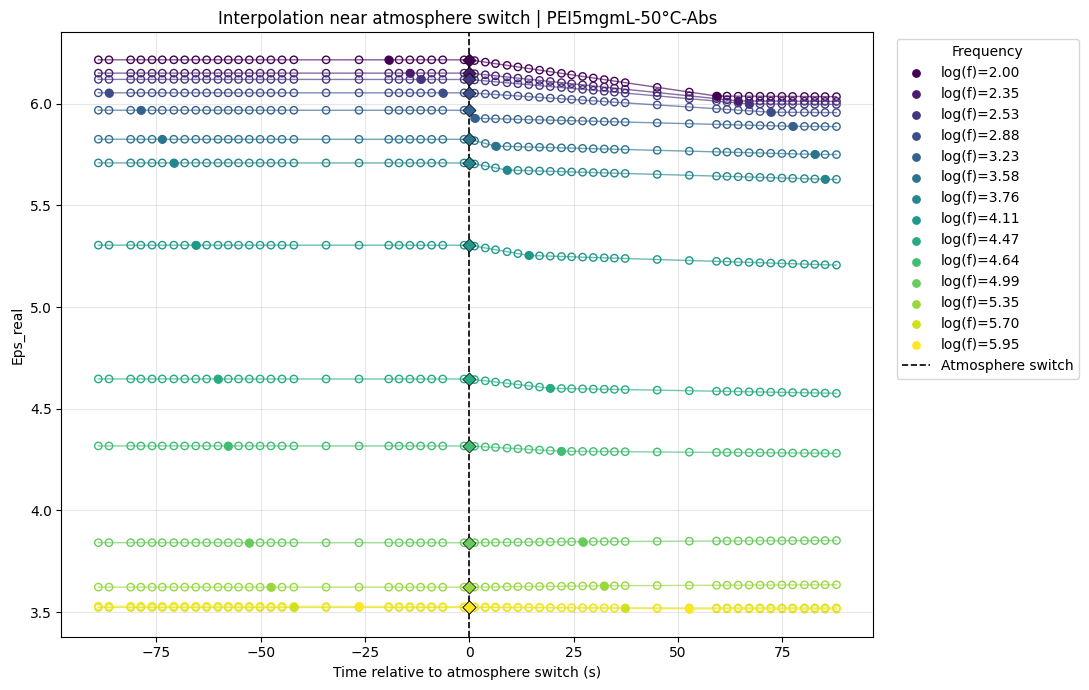

In [67]:
plot_interpolation_near_switch(
    df_all,
    df_interpolated_complete,
    material=MATERIAL,
    temperature=TEMPERATURE,
    mode=MODE,
    y_col="Eps_real",
    plot_window_s=90,
    frequency_count=14,
)

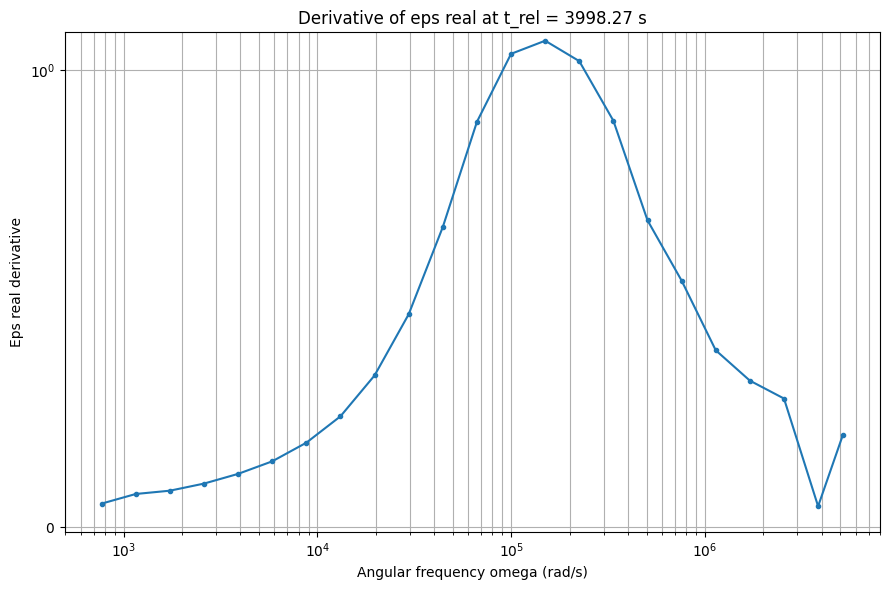

In [75]:
plot_derivative_spectrum(
    df_derivative,
    material=MATERIAL,
    temperature=TEMPERATURE,
    mode=MODE,
    target_time=PLOT_TIME_S,
)

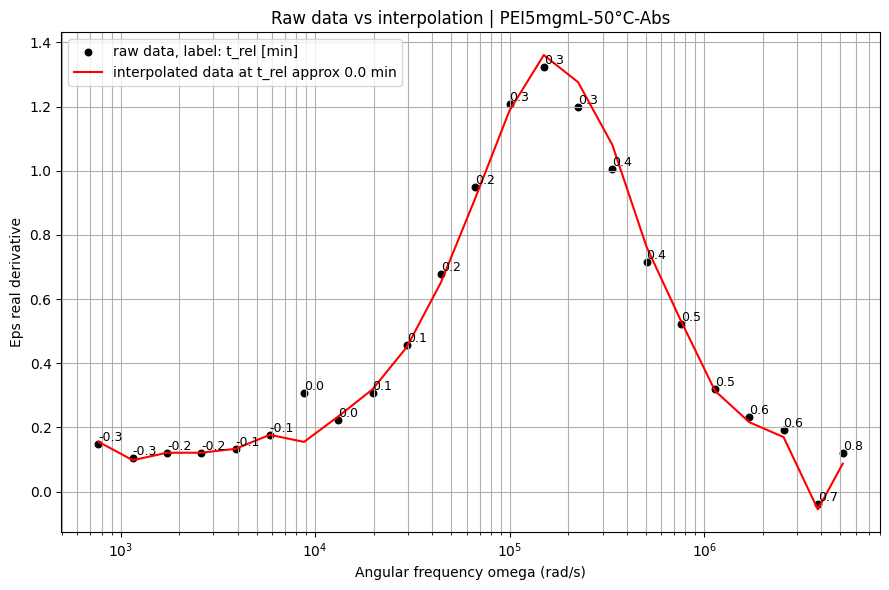

In [69]:
plot_raw_vs_interpolated_derivative(
    df_derivative,
    df_raw_derivative,
    material=MATERIAL,
    temperature=TEMPERATURE,
    mode=MODE,
    target_time=PLOT_TIME_S,
)